# Proyecto 3
## Ricardo Rodríguez

### 1. Introducción teórica.
- Mensajes spam: Son aquellos no deseados, suelen ser enviados de forma masiva por motivos publicitarios, fraudulentos o maliciosos.
- Mensajes ham: Son aquellos que si son deseados, como correos personales, laborales, académicos o notificaciones importantes.

Es relevante diferenciarlos para evitar que la bandeja del usuario se llene de correos no útiles, lo cual podría desviar la atención a los que si son importantes. El reconocimiento automático de estos textos se puede realizar mediante algún modelo de aprendizaje automático, entrenado específicamente para encontrar las características de correos spam.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import Counter
from wordcloud import WordCloud
import nltk
import string
import re
from nltk.corpus import wordnet
from nltk import pos_tag
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

### 2. Carga y exploración de los datos.

In [5]:
# Carga del archivo.
DATA_PATH = 'spam_ham.xlsx'
df = pd.read_excel(DATA_PATH)

In [6]:
# Muestra de 5 mensajes aleatorios
df.sample(5)

,Label,SMS_TEXT
3642,ham,"Sorry, left phone upstairs. OK, might be hecti..."
2438,ham,Rightio. 11.48 it is then. Well arent we all u...
4176,ham,Ok lor then we go tog lor...
3510,ham,I'm serious. You are in the money base
2971,ham,Sary just need Tim in the bollox &it hurt him ...


In [7]:
# Cantidad total de mensajes.
df.shape[0]

5565

In [8]:
df['Label'].unique()

array(['ham', 'spam', 'ham"""'], dtype=object)

In [9]:
# Tabla de distribución.
df['Label'] = df['Label'].replace({'ham"""': 'ham'})
class_counts = df['Label'].value_counts()
class_proportions = df['Label'].value_counts(normalize=True) * 100

distribution_table = pd.DataFrame({'cantidad': class_counts, 'proporcion_%': class_proportions.round(2)})
distribution_table

,cantidad,proporcion_%
Label,,
ham,4819,86.59
spam,746,13.41


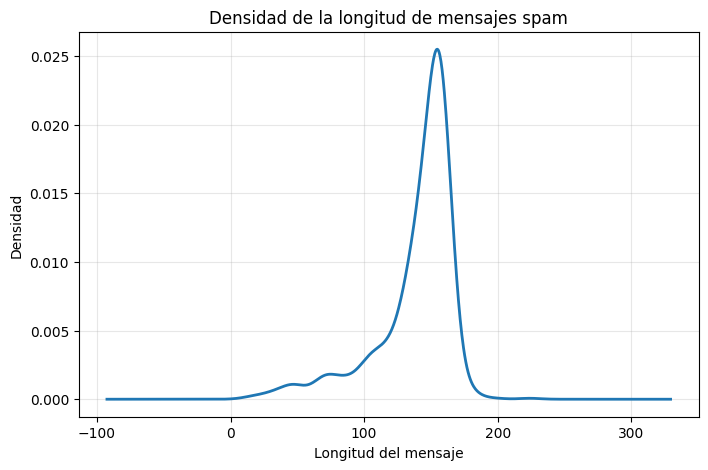

In [10]:
# Gráfica de densidad de longitud de mensajes spam.
df['longitud'] = df['SMS_TEXT'].str.len()
spam_lengths = df.loc[df["Label"] == 'spam', 'longitud']

plt.figure(figsize=(8, 5))
spam_lengths.plot(kind='density', linewidth=2)
plt.title('Densidad de la longitud de mensajes spam')
plt.xlabel('Longitud del mensaje')
plt.ylabel('Densidad')
plt.grid(alpha=0.3)
plt.show()

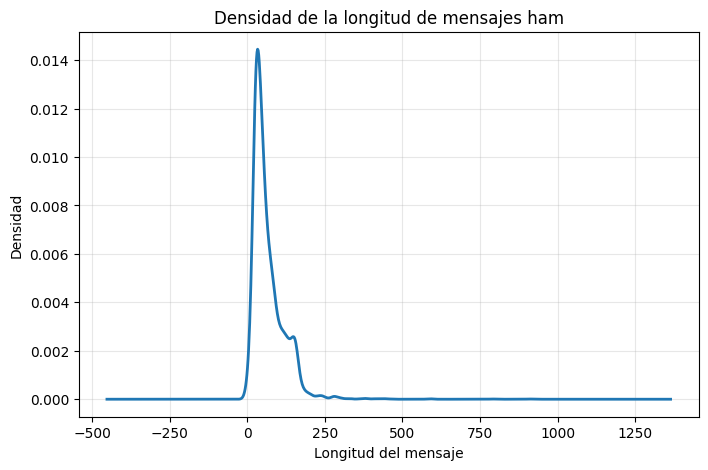

In [11]:
# Gráfica de densidad de longitud de mensajes ham.
df['longitud'] = df['SMS_TEXT'].str.len()
spam_lengths = df.loc[df["Label"] == 'ham', 'longitud']

plt.figure(figsize=(8, 5))
spam_lengths.plot(kind='density', linewidth=2)
plt.title('Densidad de la longitud de mensajes ham')
plt.xlabel('Longitud del mensaje')
plt.ylabel('Densidad')
plt.grid(alpha=0.3)
plt.show()

Hay muchas mensajes que tienen muchísima longitud, se realizará la comparación después del preprocesamiento con el fin de observar cuánto se reduce la complejidad de la entrada.

In [13]:
# Top 20 palabras más frecuentes de mensajes spam.
spam_texts = df.loc[df['Label'] == 'spam', 'SMS_TEXT']
spam_tokens = []

for message in spam_texts:
    spam_tokens.extend(str(message).split())
    
spam_word_counts = Counter(spam_tokens)
top_spam_words = pd.DataFrame(spam_word_counts.most_common(20), columns=['word', 'frequency'])
top_spam_words

,word,frequency
0,to,604
1,a,358
2,your,187
3,or,184
4,call,183
5,the,178
6,for,169
7,2,168
8,you,164
9,is,143


In [14]:
# Top 20 palabras más frecuentes de mensajes ham.
ham_texts = df.loc[df['Label'] == 'ham', 'SMS_TEXT']
ham_tokens = []

for message in ham_texts:
    ham_tokens.extend(str(message).split())

ham_word_counts = Counter(ham_tokens)
top_ham_words = pd.DataFrame(ham_word_counts.most_common(20), columns=['word', 'frequency'])
top_ham_words

,word,frequency
0,to,1451
1,you,1403
2,I,1390
3,the,972
4,a,941
5,in,707
6,and,707
7,i,706
8,u,615
9,is,602


Se observa que la mayoría de las palabras más frecuentes, son palabras que contienen poca información, como verbos auxiliares, pronombres y determinantes.

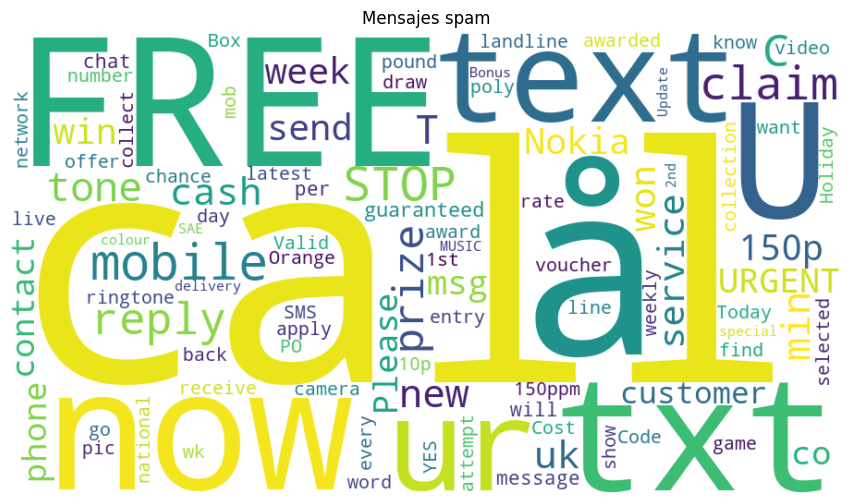

In [16]:
# WordCloud para spam

spam_text_clean = ' '.join(spam_tokens)

spam_wordcloud = WordCloud(
    width=900,
    height=500,
    background_color='white',
    max_words=100,
    collocations=False,
    random_state=0
).generate(spam_text_clean)

plt.figure(figsize=(12, 6))
plt.imshow(spam_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Mensajes spam')
plt.show()

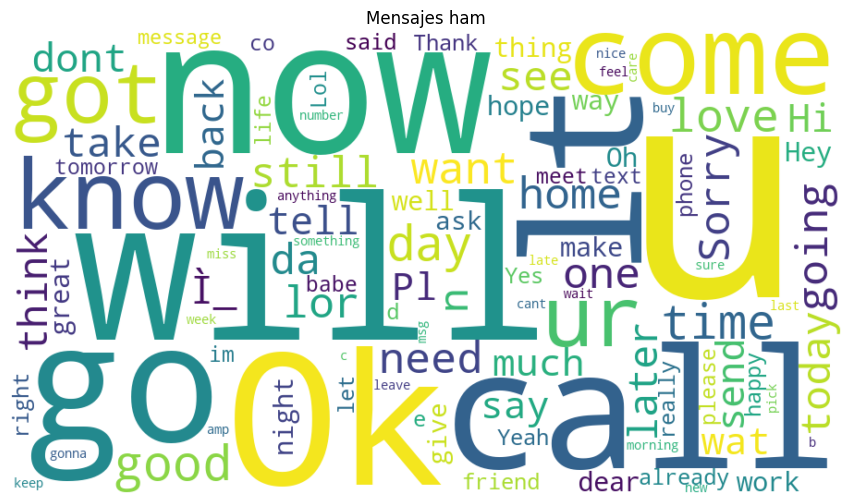

In [17]:
# WordCloud para ham

ham_text_clean = ' '.join(ham_tokens)

ham_wordcloud = WordCloud(
    width=900,
    height=500,
    background_color='white',
    max_words=100,
    collocations=False,
    random_state=0
).generate(ham_text_clean)

plt.figure(figsize=(12, 6))
plt.imshow(ham_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Mensajes ham')
plt.show()

Se puede ver que en los mensajes ham, hay más palabras mal escritas o muy informales.

### 3. Preprocesamiento de texto.

In [20]:
# Eliminar nulos.
df = df.dropna(subset = ['SMS_TEXT'])
df['SMS_TEXT'] = df['SMS_TEXT'].astype(str)

In [21]:
# Tokenización.
df['tokens'] = df['SMS_TEXT'].apply(word_tokenize)

In [22]:
# Volviendo tokens a minúsculas.
df["tokens_lower"] = df["tokens"].apply(lambda tokens: [token.lower() for token in tokens])

In [23]:
# Removiendo signos de puntuación.
def remove_punctuation(tokens):
    tokens_without_punctuation = []
    for token in tokens:
        token_clean = token.translate(str.maketrans("", "", string.punctuation))
        if token_clean != "":
            tokens_without_punctuation.append(token_clean)
    return tokens_without_punctuation

df["tokens_no_punct"] = df["tokens_lower"].apply(remove_punctuation)

In [24]:
# Removiendo stop-words.
stop_words = set(stopwords.words("english"))

def remove_stopwords(tokens):
    tokens_without_stopwords = [token for token in tokens if token not in stop_words]
    return tokens_without_stopwords
df["tokens_no_stopwords"] = df["tokens_no_punct"].apply(remove_stopwords)

In [25]:
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith("J"):
        return wordnet.ADJ
    elif treebank_tag.startswith("V"):
        return wordnet.VERB
    elif treebank_tag.startswith("N"):
        return wordnet.NOUN
    elif treebank_tag.startswith("R"):
        return wordnet.ADV
    else:
        return wordnet.NOUN
        
def lemmatize_tokens(tokens):
    tagged_tokens = pos_tag(tokens)
    lemmatized_tokens = [lemmatizer.lemmatize(word=token, pos=get_wordnet_pos(pos)) for token, pos in tagged_tokens]
    return lemmatized_tokens
    
df['mensaje'] = df['tokens_no_stopwords'].apply(lemmatize_tokens)

Se usa lematización debido a que es más precisa, aunque es un poco más lenta se priorizará la exactitud. Además Stemming puede ser una mala opción ya que genera palabras que no existen.

In [27]:
# Nos quedamos con las columnas necesarias.
df = df[['Label', 'mensaje']]

### 4. Análisis posterior al preprocesamiento.

In [29]:
# Mostramos 5 elementos.
df.head()

,Label,mensaje
0,ham,"[go, jurong, point, crazy, available, bugis, n..."
1,ham,"[ok, lar, joking, wif, u, oni]"
2,spam,"[free, entry, 2, wkly, comp, win, fa, cup, fin..."
3,ham,"[u, dun, say, early, hor, u, c, already, say]"
4,ham,"[nah, nt, think, go, usf, life, around, though]"


In [30]:
df.shape[0]

5562

In [31]:
# Tabla de distribución.
df['Label'] = df['Label'].replace({'ham"""': 'ham'})
class_counts = df['Label'].value_counts()
class_proportions = df['Label'].value_counts(normalize=True) * 100

distribution_table = pd.DataFrame({'cantidad': class_counts, 'proporcion_%': class_proportions.round(2)})
distribution_table

,cantidad,proporcion_%
Label,,
ham,4816,86.59
spam,746,13.41


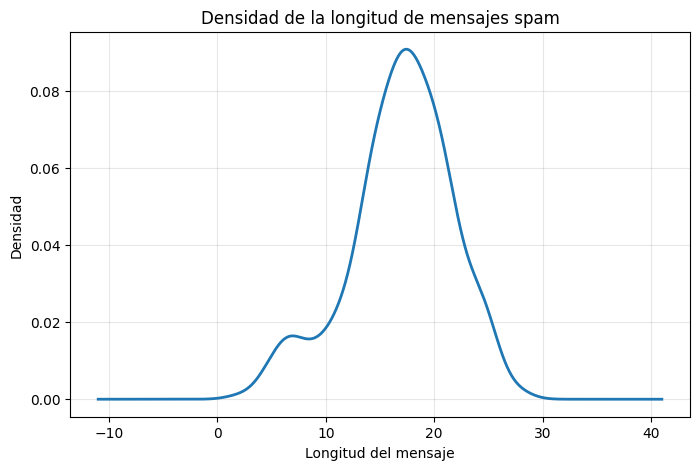

In [32]:
# Gráfica de densidad de longitud de mensajes spam.
df['longitud'] = [len(x) for x in df['mensaje']]
spam_lengths = df.loc[df["Label"] == 'spam', 'longitud']

plt.figure(figsize=(8, 5))
spam_lengths.plot(kind='density', linewidth=2)
plt.title('Densidad de la longitud de mensajes spam')
plt.xlabel('Longitud del mensaje')
plt.ylabel('Densidad')
plt.grid(alpha=0.3)
plt.show()

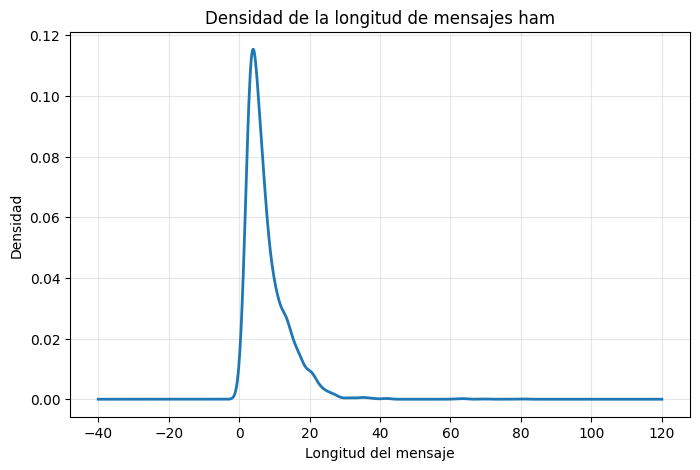

In [33]:
# Gráfica de densidad de longitud de mensajes ham.
spam_lengths = df.loc[df["Label"] == 'ham', 'longitud']

plt.figure(figsize=(8, 5))
spam_lengths.plot(kind='density', linewidth=2)
plt.title('Densidad de la longitud de mensajes ham')
plt.xlabel('Longitud del mensaje')
plt.ylabel('Densidad')
plt.grid(alpha=0.3)
plt.show()

In [34]:
# Top 20 palabras más frecuentes de mensajes spam.
spam_texts = df.loc[df['Label'] == 'spam', 'mensaje']
spam_tokens = []

for message in spam_texts:
    spam_tokens.extend(message)
    
spam_word_counts = Counter(spam_tokens)
top_spam_words = pd.DataFrame(spam_word_counts.most_common(20), columns=['word', 'frequency'])
top_spam_words

,word,frequency
0,call,364
1,free,219
2,2,175
3,u,167
4,txt,156
5,ur,143
6,text,137
7,mobile,134
8,4,123
9,stop,116


In [35]:
# Top 20 palabras más frecuentes de mensajes ham.
ham_texts = df.loc[df['Label'] == 'ham', 'mensaje']
ham_tokens = []

for message in ham_texts:
    ham_tokens.extend(message)

ham_word_counts = Counter(ham_tokens)
top_ham_words = pd.DataFrame(ham_word_counts.most_common(20), columns=['word', 'frequency'])
top_ham_words

,word,frequency
0,u,999
1,get,577
2,go,504
3,nt,341
4,come,311
5,2,286
6,call,282
7,ok,274
8,know,247
9,lt,239


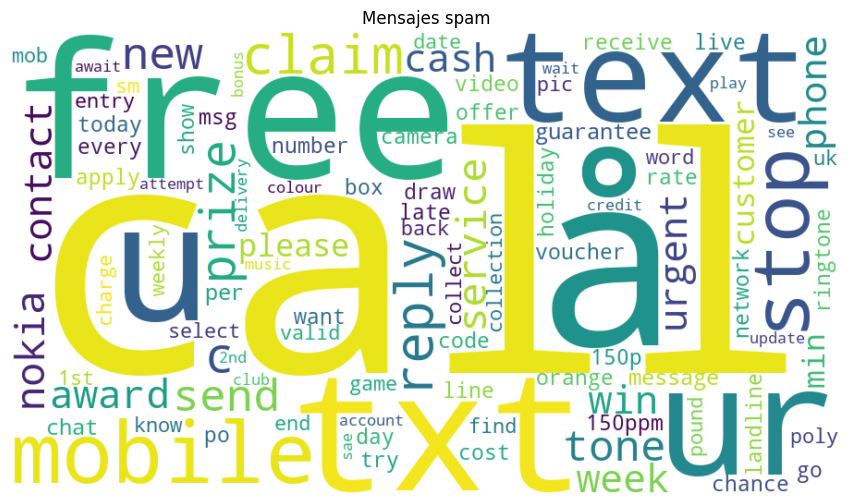

In [36]:
# WordCloud para spam
spam_text_clean = ' '.join(spam_tokens)

spam_wordcloud = WordCloud(
    width=900,
    height=500,
    background_color='white',
    max_words=100,
    collocations=False,
    random_state=0
).generate(spam_text_clean)

plt.figure(figsize=(12, 6))
plt.imshow(spam_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Mensajes spam')
plt.show()

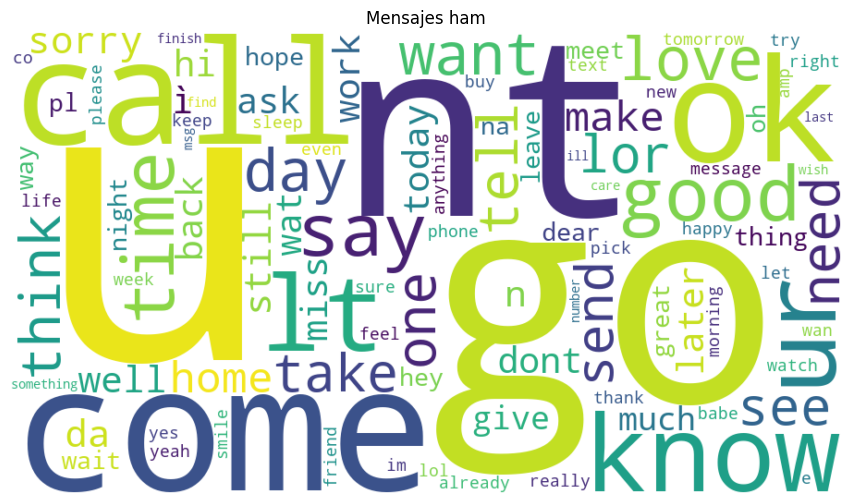

In [37]:
# WordCloud para ham.

ham_text_clean = ' '.join(ham_tokens)

ham_wordcloud = WordCloud(
    width=900,
    height=500,
    background_color='white',
    max_words=100,
    collocations=False,
    random_state=0
).generate(ham_text_clean)

plt.figure(figsize=(12, 6))
plt.imshow(ham_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Mensajes ham')
plt.show()

### 5. Reflexión y análisis.

##### ¿Qué cambios son más notorios entre los indicadores antes y después del preprocesamiento?

La longitud de los mensajes cambió mucho, ya no hay textos de longitud mayor a 125, esto nos reduce la complejidad del modelo y nos asegura de que tenemos datos mucho más importantes a los que se tenían en un inicio.

##### Respecto a las 20 palabras más frecuentes en ambos grupos:
- ¿Hay palabras en común entre spam y ham? Si, está call, 2 y u. Se evaluará si es necesario eliminar aquellas palabras menores a 3 letras.
- ¿Qué palabras son exclusivas de cada clase? Free y txt son palabras muy exclusiva de los mensajes spam, mientras que go, ok y nt son palabras más exclusivas de los mensajes spam.
- ¿Qué información o patrones puede deducir de estas diferencias? Que habrán ciertas palabras que serán mucho más informativas para diferenciar entre tipos de mensaje y al evaluar todas las palabras del mensaje se puede obtener una probabilidad de que sea spam o ham.

##### Según su análisis exploratorio, ¿qué características del texto podrían ser útiles para distinguir entre un mensaje spam y uno ham?

Aquellas palabras que son más comunes en los mensajes spam, pero no en los ham y aquellas que son más comunes en los mensajes ham, pero no en los spam.

### 5. Modelo

##### Librerías para hacer el modelo

In [46]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.metrics import classification_report, confusion_matrix, precision_score, make_scorer

##### Se separan los datos de las etiquetas.

In [48]:
X = df['mensaje']
y = df['Label']

##### Se realiza la separación de conjunto de entrenamiento y prueba.

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=0, stratify=y)

##### Se crea el pipeline en el que se tiene el TFIDF y el modelo Naive Bayes Mulinomial.

In [52]:
pipeline = Pipeline(
    steps=[('tfidf',
            TfidfVectorizer(
                tokenizer=lambda tokens: [str(token) for token in tokens],
                preprocessor=lambda tokens: tokens,
                token_pattern=None,
                lowercase=False)
           ),
           ('modelo',
            MultinomialNB()
           )])

##### Uso 

In [54]:
precision_spam = make_scorer(
    precision_score,
    pos_label=1,
    zero_division=0
)

##### Rejilla de parámetros.

In [56]:
param_grid = [
    {
        "tfidf__ngram_range": [(1, 2), (1, 3)],
        "tfidf__min_df": [1, 2, 3],
        "tfidf__max_df": [0.8, 0.90],
        "tfidf__sublinear_tf": [True],
        "tfidf__use_idf": [True],
        "tfidf__smooth_idf": [True],
        "tfidf__norm": ["l2"],
        "modelo": [MultinomialNB()],
        "modelo__alpha": [0.01, 0.015],
        "modelo__fit_prior": [True]
    }
]

##### Validación cruzada estratificada.

In [58]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

##### Modelo que se entrenará con validación cruzada.

In [60]:
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=precision_spam,
    cv=cv,
    n_jobs=-1,
    verbose=2,
    refit=True,
    return_train_score=True
)

##### Entrenamiento del modelo.

In [62]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


C:\Users\ricro\AppData\Roaming\Python\Python311\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan]
  warnings.warn(
C:\Users\ricro\AppData\Roaming\Python\Python311\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the train scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan]
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...inomialNB())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'modelo': [MultinomialNB()], 'modelo__alpha': [0.01, 0.015], 'modelo__fit_prior': [True], 'tfidf__max_df': [0.8, 0.9], ...}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(p...ro_division=0)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messag

##### Mejores parámetros

In [64]:
print("Mejor score de validación cruzada:")
print(grid_search.best_score_)

print("\nMejores hiperparámetros:")
print(grid_search.best_params_)

Mejor score de validación cruzada:
nan

Mejores hiperparámetros:
{'modelo': MultinomialNB(), 'modelo__alpha': 0.01, 'modelo__fit_prior': True, 'tfidf__max_df': 0.8, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2), 'tfidf__norm': 'l2', 'tfidf__smooth_idf': True, 'tfidf__sublinear_tf': True, 'tfidf__use_idf': True}


##### Mejor modelo.

In [67]:
X_train_texto = [" ".join(tokens) for tokens in X_train]
modelo = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        token_pattern=r"(?u)\b\w+\b",
        ngram_range=(1, 2),
        min_df=1,
        max_df=0.8,
        sublinear_tf=True,
        use_idf=True,
        smooth_idf=True,
        norm="l2"
    )),
    ("modelo", MultinomialNB(
        alpha=0.01,
        fit_prior=True
    ))
])

modelo.fit(X_train_texto, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


### 6. Pruebas de rendimiento.

##### Predicción del modelo.

In [71]:
X_test_texto = [" ".join(tokens) for tokens in X_test]
y_pred = modelo.predict(X_test_texto)

##### Métricas y matriz de confusión.

In [74]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["ham", "spam"]
))

confusion_matrix(y_test, y_pred)

              precision    recall  f1-score   support

         ham       0.98      0.99      0.99       964
        spam       0.95      0.89      0.92       149

    accuracy                           0.98      1113
   macro avg       0.97      0.94      0.95      1113
weighted avg       0.98      0.98      0.98      1113



array([[957,   7],
       [ 16, 133]], dtype=int64)

In [ ]:
print("Mejor score de validación cruzada:")
print(grid_search.best_score_)

print("\nMejores hiperparámetros:")
print(grid_search.best_params_)

### 7. Presentación.

In [ ]:
spam = "spam"

texto = input("Mensaje: ")

# Predicción
probabilidades = modelo.predict_proba([texto])[0]

nb = modelo.named_steps["modelo"]
vec = modelo.named_steps["tfidf"]

# Buscar índice de la clase spam
i_spam = list(nb.classes_).index(spam)

prob_spam = probabilidades[i_spam]

print(f"Probabilidad de spam: {prob_spam:.4f}")

# Vectorizar el mensaje
x = vec.transform([texto])

# Vocabulario aprendido
V = vec.get_feature_names_out()

# Si el mensaje no tiene palabras reconocidas
if x.nnz == 0:
    print("El modelo no reconoció ninguna palabra del mensaje.")
    print("Top 3 palabras: []")
else:
    # Probabilidades P(w | clase)
    p_w_c = np.exp(nb.feature_log_prob_)

    # Probabilidades P(clase)
    p_c = np.exp(nb.class_log_prior_)

    # P(spam | palabra), usando Bayes
    p_spam_w = (p_w_c[i_spam] * p_c[i_spam]) / (p_w_c.T @ p_c)

    # Índices de las palabras presentes en el mensaje
    indices_presentes = x.nonzero()[1]

    # Quedarnos solo con unigramas, no bigramas
    indices_palabras = [
        j for j in indices_presentes
        if " " not in V[j]
    ]

    if len(indices_palabras) == 0:
        print("El mensaje solo tiene bigramas reconocidos o ninguna palabra individual reconocida.")
        print("Top 3 palabras: []")
    else:
        top_3 = sorted(
            zip(V[indices_palabras], p_spam_w[indices_palabras]),
            key=lambda z: z[1],
            reverse=True
        )[:3]

        print("Top 3 palabras:", top_3)